# Day 7: Session 7A - The Anatomy of a Figure

[Session Webpage](https://eds-217-essential-python.github.io/course-materials/interactive-sessions/7a_matplotlib.html)

Date: 09/09/2026

plt.plot(monthly_means)

plt.title("Toolik Monthly Temperatures")

plt.xlabel("Month")

plt.ylabel("Temperature (°C)")

plt.show()

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

url = 'https://eds-217-essential-python.github.io/data/toolik_weather.csv'
toolik = pd.read_csv(url)

toolik['date'] = pd.to_datetime(toolik['Date'], format='%Y%m%d')
toolik['year'] = toolik['date'].dt.year
toolik['month'] = toolik['date'].dt.month

toolik.shape

(11171, 24)

In [2]:
toolik.head()

,Year,Month,Date,LTER_Site,Station,Daily_AirTemp_Mean_C,Flag_Daily_AirTemp_Mean_C,Daily_AirTemp_AbsMax_C,Flag_Daily_AirTemp_AbsMax_C,Daily_AirTemp_AbsMin_C,...,FLAG_Daily_windsp_mean_msec,Daily_Windspeed_AbsMax_m_s,Daily_globalrad_total_jcm2,FLAG_Daily_globalrad_total_mjm2,Moss,Soil20cm,Comments,date,year,month
0,1988,6,19880601,ARC,TLKMAIN,8.4,E,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Air temp 1 & 5 meter estimated from regressio...,1988-06-01,1988,6
1,1988,6,19880602,ARC,TLKMAIN,6.0,E,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Air temp 1 & 5 meter estimated from regressio...,1988-06-02,1988,6
2,1988,6,19880603,ARC,TLKMAIN,5.8,E,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Air temp 1 & 5 meter estimated from regressio...,1988-06-03,1988,6
3,1988,6,19880604,ARC,TLKMAIN,1.8,E,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Air temp 1 & 5 meter estimated from regressio...,1988-06-04,1988,6
4,1988,6,19880605,ARC,TLKMAIN,6.8,E,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Air temp 1 & 5 meter estimated from regressio...,1988-06-05,1988,6


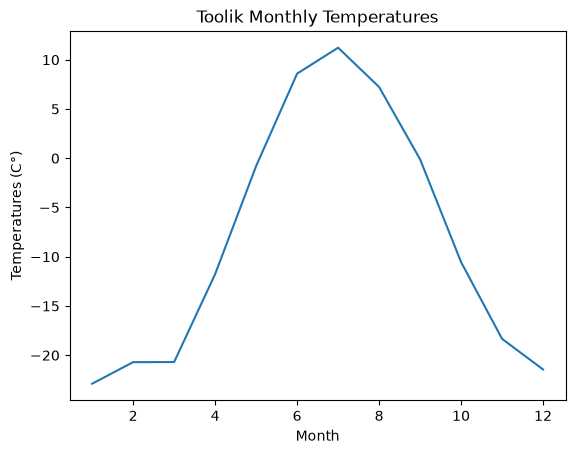

In [3]:
monthly_means = toolik.groupby('month')['Daily_AirTemp_Mean_C'].mean()

plt.plot(monthly_means)
plt.title('Toolik Monthly Temperatures')
plt.xlabel('Month')
plt.ylabel('Temperatures (C°)')
plt.show()

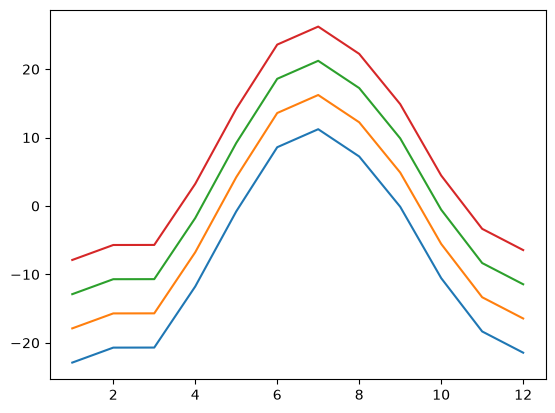

In [9]:
plt.plot(monthly_means)
plt.plot(monthly_means + 5)
plt.plot(monthly_means + 10)
plt.plot(monthly_means + 15)
plt.show()

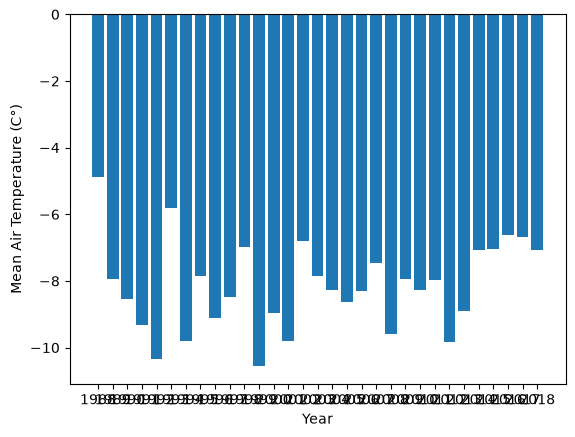

In [11]:
annual_means = toolik.groupby('year')['Daily_AirTemp_Mean_C'].mean()

plt.bar(annual_means.index.astype(str), annual_means)
plt.xlabel('Year')
plt.ylabel('Mean Air Temperature (C°)')
plt.show()


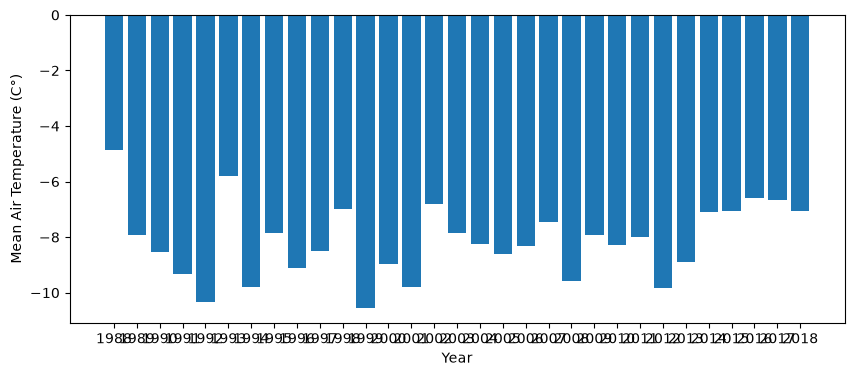

In [13]:
plt.figure(figsize = (10, 4)) # this is the dimenstions that the plot will fit into `plt.figure(figsize = (width, height))`

plt.bar(annual_means.index.astype(str), annual_means)
plt.xlabel('Year')
plt.ylabel('Mean Air Temperature (C°)')
plt.show()


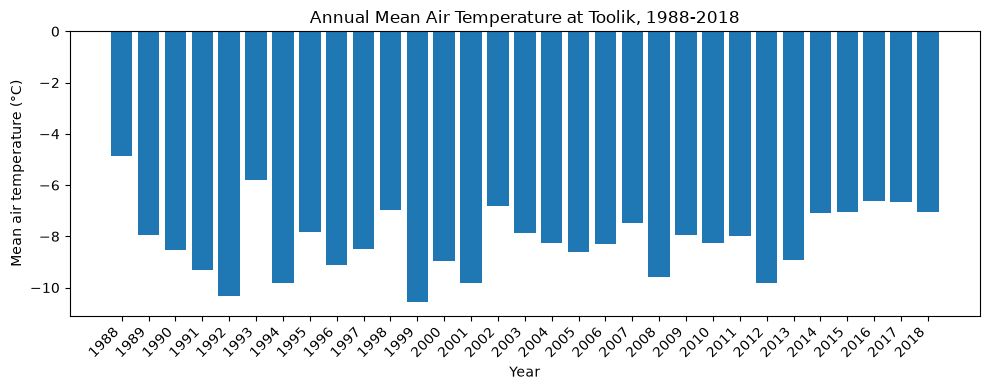

In [ ]:
plt.figure(figsize=(10, 4))

plt.bar(annual_means.index.astype(str), annual_means)
plt.xticks(rotation=45, ha='right') # this will change the angle of the x-axis ( dont go past 60 )
plt.xlabel('Year')
plt.ylabel('Mean air temperature (°C)')
plt.title('Annual Mean Air Temperature at Toolik, 1988-2018')
plt.tight_layout() # this makes sure we do not clip the axes...
plt.show()

### every figure needs three things 
plt.xlabel('what is along the bottom, with units')

plt.ylabel('what is up the side, with units')

plt.title('what this figure is of')

In [29]:
early = toolik[toolik['year'] <= 1998]
late = toolik[toolik['year'] >= 2009]

comparison = pd.DataFrame({
    'early': early.groupby('month')['Daily_AirTemp_Mean_C'].mean(),
    'late': late.groupby('month')['Daily_AirTemp_Mean_C'].mean()
})

comparison['change'] = comparison['late'] - comparison['early']

comparison.round(3)

,early,late,change
month,,,
1,-24.718,-21.259,3.460
2,-21.859,-19.383,2.476
3,-18.617,-20.639,-2.022
4,-10.405,-11.859,-1.454
5,0.367,-0.540,-0.907
6,8.427,8.192,-0.235
7,12.048,11.282,-0.767
8,7.479,7.178,-0.302
9,-0.850,-0.010,0.841


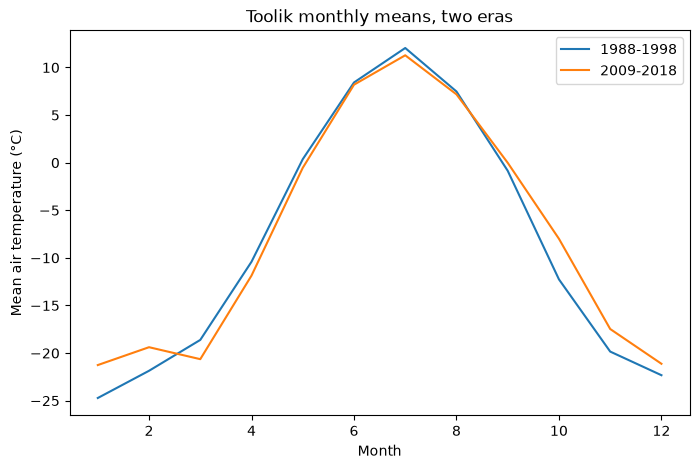

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(comparison.index, comparison['early'], label='1988-1998')
plt.plot(comparison.index, comparison['late'], label='2009-2018')

plt.xlabel('Month')
plt.ylabel('Mean air temperature (°C)')
plt.title('Toolik monthly means, two eras')
plt.legend()
plt.show()

plt.plot(x, x, label = 'what this line is') # once per series

plt.legend() # once per figure

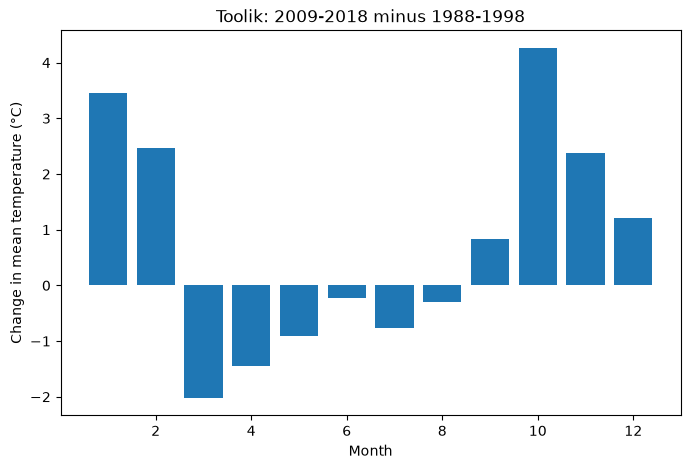

In [31]:
plt.figure(figsize=(8, 5))

plt.bar(comparison.index, comparison['change'])

plt.xlabel('Month')
plt.ylabel('Change in mean temperature (°C)')
plt.title('Toolik: 2009-2018 minus 1988-1998')
plt.show()

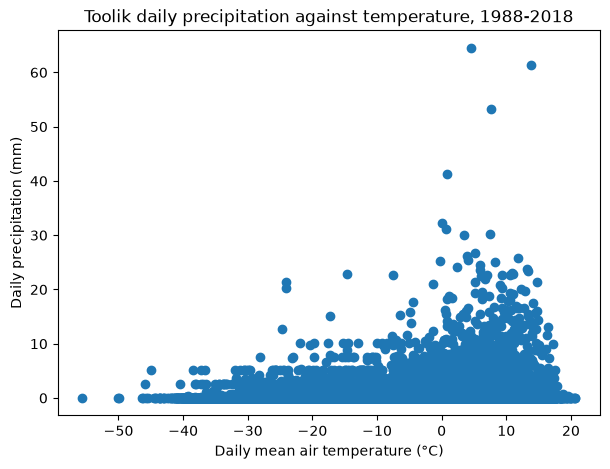

In [32]:
wet_days = toolik.dropna(subset=['Daily_Precip_Total_mm'])

plt.figure(figsize=(7, 5))

plt.scatter(wet_days['Daily_AirTemp_Mean_C'], wet_days['Daily_Precip_Total_mm'])

plt.xlabel('Daily mean air temperature (°C)')
plt.ylabel('Daily precipitation (mm)')
plt.title('Toolik daily precipitation against temperature, 1988-2018')
plt.show()